In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import umap
from safetensors.torch import load_file

In [91]:
sd = load_file(
    "/home/user/zihancao/Project/hyperspectral-1d-tokenizer/runs/stage1_cosmos_hybrid/2025-11-03_16-44-51_hybrid_cosmos_f16c64/ema/tokenizer/model.safetensors"
)
for k, v in sd.items():
    # if "conv_out" in k:
    print(k, v.shape)
# kernel = sd["encoder.encoder.conv_out.weight"]
kernel = sd["decoder.decoder.conv_out.conv.weight"]
print(kernel.shape)

_repa_proj.low_lvl_repa_proj.0.0.bias torch.Size([256])
_repa_proj.low_lvl_repa_proj.0.0.weight torch.Size([256])
_repa_proj.low_lvl_repa_proj.0.1.bias torch.Size([1024])
_repa_proj.low_lvl_repa_proj.0.1.weight torch.Size([1024, 256, 1, 1])
_repa_proj.low_lvl_repa_proj.0.2.bias torch.Size([1024])
_repa_proj.low_lvl_repa_proj.0.2.weight torch.Size([1024])
_repa_proj.low_lvl_repa_proj.0.3.bias torch.Size([1024])
_repa_proj.low_lvl_repa_proj.0.3.weight torch.Size([1024, 1024, 1, 1])
_repa_proj.low_lvl_repa_proj.1.0.bias torch.Size([512])
_repa_proj.low_lvl_repa_proj.1.0.weight torch.Size([512])
_repa_proj.low_lvl_repa_proj.1.1.bias torch.Size([1024])
_repa_proj.low_lvl_repa_proj.1.1.weight torch.Size([1024, 512, 1, 1])
_repa_proj.low_lvl_repa_proj.1.2.bias torch.Size([1024])
_repa_proj.low_lvl_repa_proj.1.2.weight torch.Size([1024])
_repa_proj.low_lvl_repa_proj.1.3.bias torch.Size([1024])
_repa_proj.low_lvl_repa_proj.1.3.weight torch.Size([1024, 1024, 1, 1])
_repa_proj.low_lvl_repa_proj.2

In [ ]:
# normalize
kf = kernel.transpose(0, 1).flatten(1).cpu().numpy()  # (C_out, C_in*K*K)
kf = (kf - kf.mean(axis=1, keepdims=True)) / kf.std(axis=1, keepdims=True)

reducer = umap.UMAP(n_neighbors=3, min_dist=0.05, n_components=2, random_state=42)
embedding = reducer.fit_transform(kf)  # (C_out, 2)
print(embedding.shape)

/home/user/miniconda3/envs/zihan/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(512, 2)


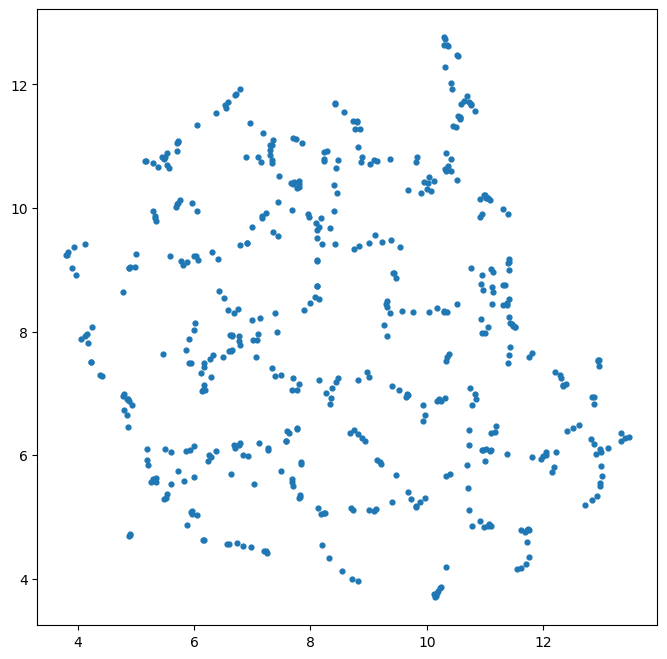

In [ ]:
# plot in 3d axes
from mpl_toolkits.mplot3d import Axes3D

# plot
if embedding.shape[1] == 3:
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], s=12)
else:  # plot in 2d
    plt.figure(figsize=(8, 8))
    plt.scatter(embedding[:, 0], embedding[:, 1], s=12)